# **Project Overview**:
**This project tackles a well known healthcare issue: diabetes.**

In researching a suitable dataset, I looked at the datasets provided by SKLearn.  There are some toy datasets and some more "realistic" ones provided through the Sklearn API's.  However, even the more "realistic" datasets provided (like California housing) did not provide enough information or details.

Subsequently, I looked at the datasets available on Kaggle.  And after comparing different datasets, I chose this one because the Diabetes use cases are suitable for Supervised Machine Learning.  

Namely,
1. linear regression to predict a numerical value.  This is used to predict someone's diabetes risk score.

2. And the second typical use case for supervised Machine Learning: using logistic regression, to predict a binary (yes/no) outcome indicating if someone is diagnosed with diabetes or not.  In other words, does a person have diabetes - given all the other known data about them.








Github Repository is available at this [link](https://github.com/GhassanHariz/supervisedmlfinalproj/tree/main).

# **This Supervised Machine Learning project involved  5 major phases**:
1. Import the Data from Kaggle
2. Explanatory Data Analysis (EDA) and Data Wrangling
3. Diabetes Risk Score using Linear Regression
4. Diabetes Risk Score using Linear Regression and Stochastic Gradient Descent
5. Diabetes Diagnosis Prediction using Logistic Regression for Binary Classification

# **1. Import the Diabetes Data from Kaggle**

Source: https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns

In [3]:
# Download the Dataset
import kagglehub

# Get latest version
path = kagglehub.dataset_download("mohankrishnathalla/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)

100%|██████████| 3.75M/3.75M [00:00<00:00, 40.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/versions/1


In [4]:
# Read the dataset from CSV file into data frame
df = pd.read_csv(path + '/diabetes_dataset.csv')

# **2. Explanatory Data Analysis and Data Wrangling**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [6]:
df.head(10)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,...,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,...,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,...,49,159,120,110,189,8.96,7.04,34.2,Type 2,1
8,42,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,...,33,132,98,116,172,5.70,6.90,26.7,Type 2,1
9,59,Female,White,Graduate,Middle,Employed,Current,3,86,8.2,...,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0


In [7]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


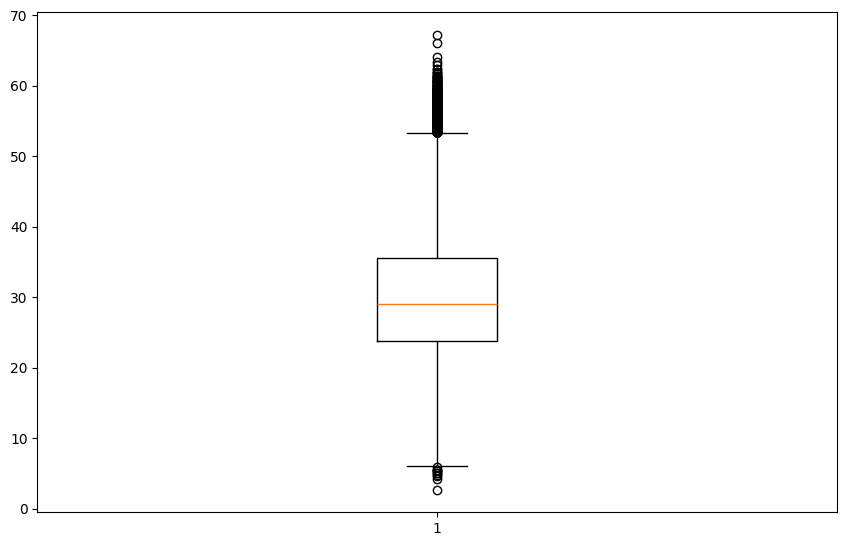

In [8]:
# Use a Box plot to see distribution of Diabetes Risk Score data
# is there any skewness, what are the outliers

fig = plt.figure(figsize =(8, 5))
ax = fig.add_axes([0, 0, 1, 1])
bp = ax.boxplot(df['diabetes_risk_score'])

plt.show()

The Box Plot shows that the majority of numbers lie around 30 value.  There are some outliers above ~55.  And less outliers less than ~12.

The same data is seen below in the Histogram

(array([1.5200e+02, 2.8140e+03, 1.4843e+04, 2.9698e+04, 2.5798e+04,
        1.3287e+04, 8.8550e+03, 3.9400e+03, 5.9100e+02, 2.2000e+01]),
 array([ 2.7 ,  9.15, 15.6 , 22.05, 28.5 , 34.95, 41.4 , 47.85, 54.3 ,
        60.75, 67.2 ]),
 <BarContainer object of 10 artists>)

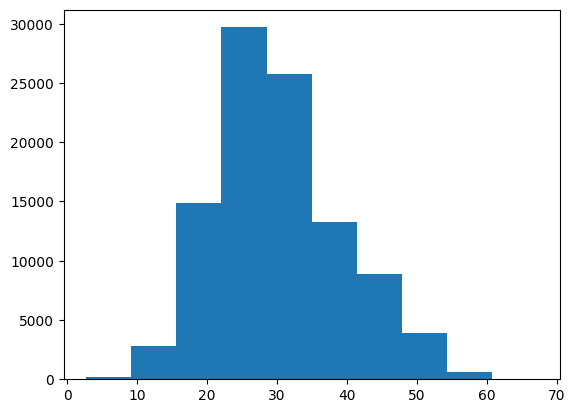

In [9]:
# The same data distribution displayed by a histogram (in bins)
plt.hist(df['diabetes_risk_score'] )

In [10]:
#See a correlation matrix - using Spearman coefficient method (default)
df.corr(numeric_only=True)

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
age,1.000000,0.000994,0.003352,-0.003326,-0.002802,-0.004704,-0.002877,0.177706,0.146797,0.092643,...,0.309717,-0.016358,0.281275,0.039449,0.231533,0.132479,0.045412,0.159447,0.495924,0.137713
alcohol_consumption_per_week,0.000994,1.000000,-0.002185,-0.000265,0.001556,0.001004,0.002531,-0.007079,-0.004311,-0.001867,...,0.002618,0.000039,0.001258,0.126674,0.006401,0.004875,0.001199,0.006174,0.010650,0.000760
physical_activity_minutes_per_week,0.003352,-0.002185,1.000000,-0.002470,-0.004735,0.000996,-0.007021,-0.001176,0.000466,-0.071907,...,-0.009555,0.018044,-0.014119,-0.026527,-0.161946,-0.093936,-0.034063,-0.112897,-0.348121,-0.100774
diet_score,-0.003326,-0.000265,-0.002470,1.000000,0.001255,0.002113,0.000336,0.001806,0.003828,-0.201303,...,-0.038603,0.042245,-0.046451,-0.080243,-0.072518,-0.044419,-0.080716,-0.054068,-0.144891,-0.044298
sleep_hours_per_day,-0.002802,0.001556,-0.004735,0.001255,1.000000,0.004732,0.003642,0.004753,-0.000437,0.000400,...,0.001996,-0.001898,0.002269,-0.003772,0.000834,0.000497,0.000433,0.001436,0.003136,-0.000399
screen_time_hours_per_day,-0.004704,0.001004,0.000996,0.002113,0.004732,1.000000,-0.001641,-0.001567,-0.002255,-0.003019,...,0.000734,-0.000931,0.001473,-0.003494,0.034692,0.020400,0.001902,0.024197,0.071284,0.018127
family_history_diabetes,-0.002877,0.002531,-0.007021,0.000336,0.003642,-0.001641,1.000000,0.003300,0.001188,0.000309,...,-0.003697,-0.006730,-0.000641,0.002813,0.344724,0.204469,0.016186,0.242136,0.733085,0.197926
hypertension_history,0.177706,-0.007079,-0.001176,0.001806,0.004753,-0.001567,0.003300,1.000000,0.022182,0.014494,...,0.049581,-0.005910,0.044854,0.008957,0.047285,0.029652,0.008807,0.032591,0.091315,0.027524
cardiovascular_history,0.146797,-0.004311,0.000466,0.003828,-0.000437,-0.002255,0.001188,0.022182,1.000000,0.009956,...,0.043271,-0.002539,0.037657,0.009128,0.036177,0.029442,0.008105,0.033310,0.072970,0.029793
bmi,0.092643,-0.001867,-0.071907,-0.201303,0.000400,-0.003019,0.000309,0.014494,0.009956,1.000000,...,0.199849,-0.211899,0.238032,0.405668,0.150929,0.092818,0.391903,0.110321,0.313813,0.097057


### Convert 3 Categorical Columns to Numerical and see if they correlate  with the Target

In [11]:
# Identifying categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_columns)

# Select a subset of categorcial columns
categorical_columns_limited = ['ethnicity', 'education_level', 'income_level']

['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'diabetes_stage']


In [12]:
# Applying one-hot encoding
encoder = OneHotEncoder(sparse_output=False)

encoded_features = encoder.fit_transform(df[categorical_columns_limited])

one_hot_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns_limited))

df_sklearn_encoded = pd.concat([df.drop(categorical_columns, axis=1), one_hot_df], axis=1)


In [13]:
print(df_sklearn_encoded.shape)

(100000, 38)


In [14]:
# See Correlation values in relation to Target - diabetes_risk_score - highest first:
correlation_values = abs(df_sklearn_encoded.corr()['diabetes_risk_score']).sort_values(ascending=False)
print(correlation_values)

diabetes_risk_score                   1.000000
family_history_diabetes               0.733085
age                                   0.495924
glucose_fasting                       0.469938
physical_activity_minutes_per_week    0.348121
hba1c                                 0.329947
systolic_bp                           0.323591
bmi                                   0.313813
diagnosed_diabetes                    0.277300
glucose_postprandial                  0.277041
waist_to_hip_ratio                    0.241651
ldl_cholesterol                       0.227772
cholesterol_total                     0.197995
triglycerides                         0.180484
hdl_cholesterol                       0.174459
diet_score                            0.144891
insulin_level                         0.142210
diastolic_bp                          0.136090
heart_rate                            0.092045
hypertension_history                  0.091315
cardiovascular_history                0.072970
screen_time_h

In [15]:
# keep the independent values - drop column that is not needed
correlation_values1_df = pd.DataFrame(correlation_values).drop('diabetes_risk_score', axis=1)
print(correlation_values1_df)
print(correlation_values1_df.shape)

# limit the list to the most correlated values
correlation_values1_limited_df = correlation_values1_df.loc[:'alcohol_consumption_per_week']
print(correlation_values1_limited_df)

# convert to a list
correlation_values1_limited_list = correlation_values1_limited_df.index.to_list()
print(correlation_values1_limited_list)

Empty DataFrame
Columns: []
Index: [diabetes_risk_score, family_history_diabetes, age, glucose_fasting, physical_activity_minutes_per_week, hba1c, systolic_bp, bmi, diagnosed_diabetes, glucose_postprandial, waist_to_hip_ratio, ldl_cholesterol, cholesterol_total, triglycerides, hdl_cholesterol, diet_score, insulin_level, diastolic_bp, heart_rate, hypertension_history, cardiovascular_history, screen_time_hours_per_day, alcohol_consumption_per_week, ethnicity_Hispanic, ethnicity_Asian, income_level_High, ethnicity_Black, income_level_Lower-Middle, ethnicity_White, education_level_Highschool, sleep_hours_per_day, ethnicity_Other, education_level_Graduate, education_level_Postgraduate, income_level_Middle, education_level_No formal, income_level_Upper-Middle, income_level_Low]
(38, 0)
Empty DataFrame
Columns: []
Index: [diabetes_risk_score, family_history_diabetes, age, glucose_fasting, physical_activity_minutes_per_week, hba1c, systolic_bp, bmi, diagnosed_diabetes, glucose_postprandial, wa

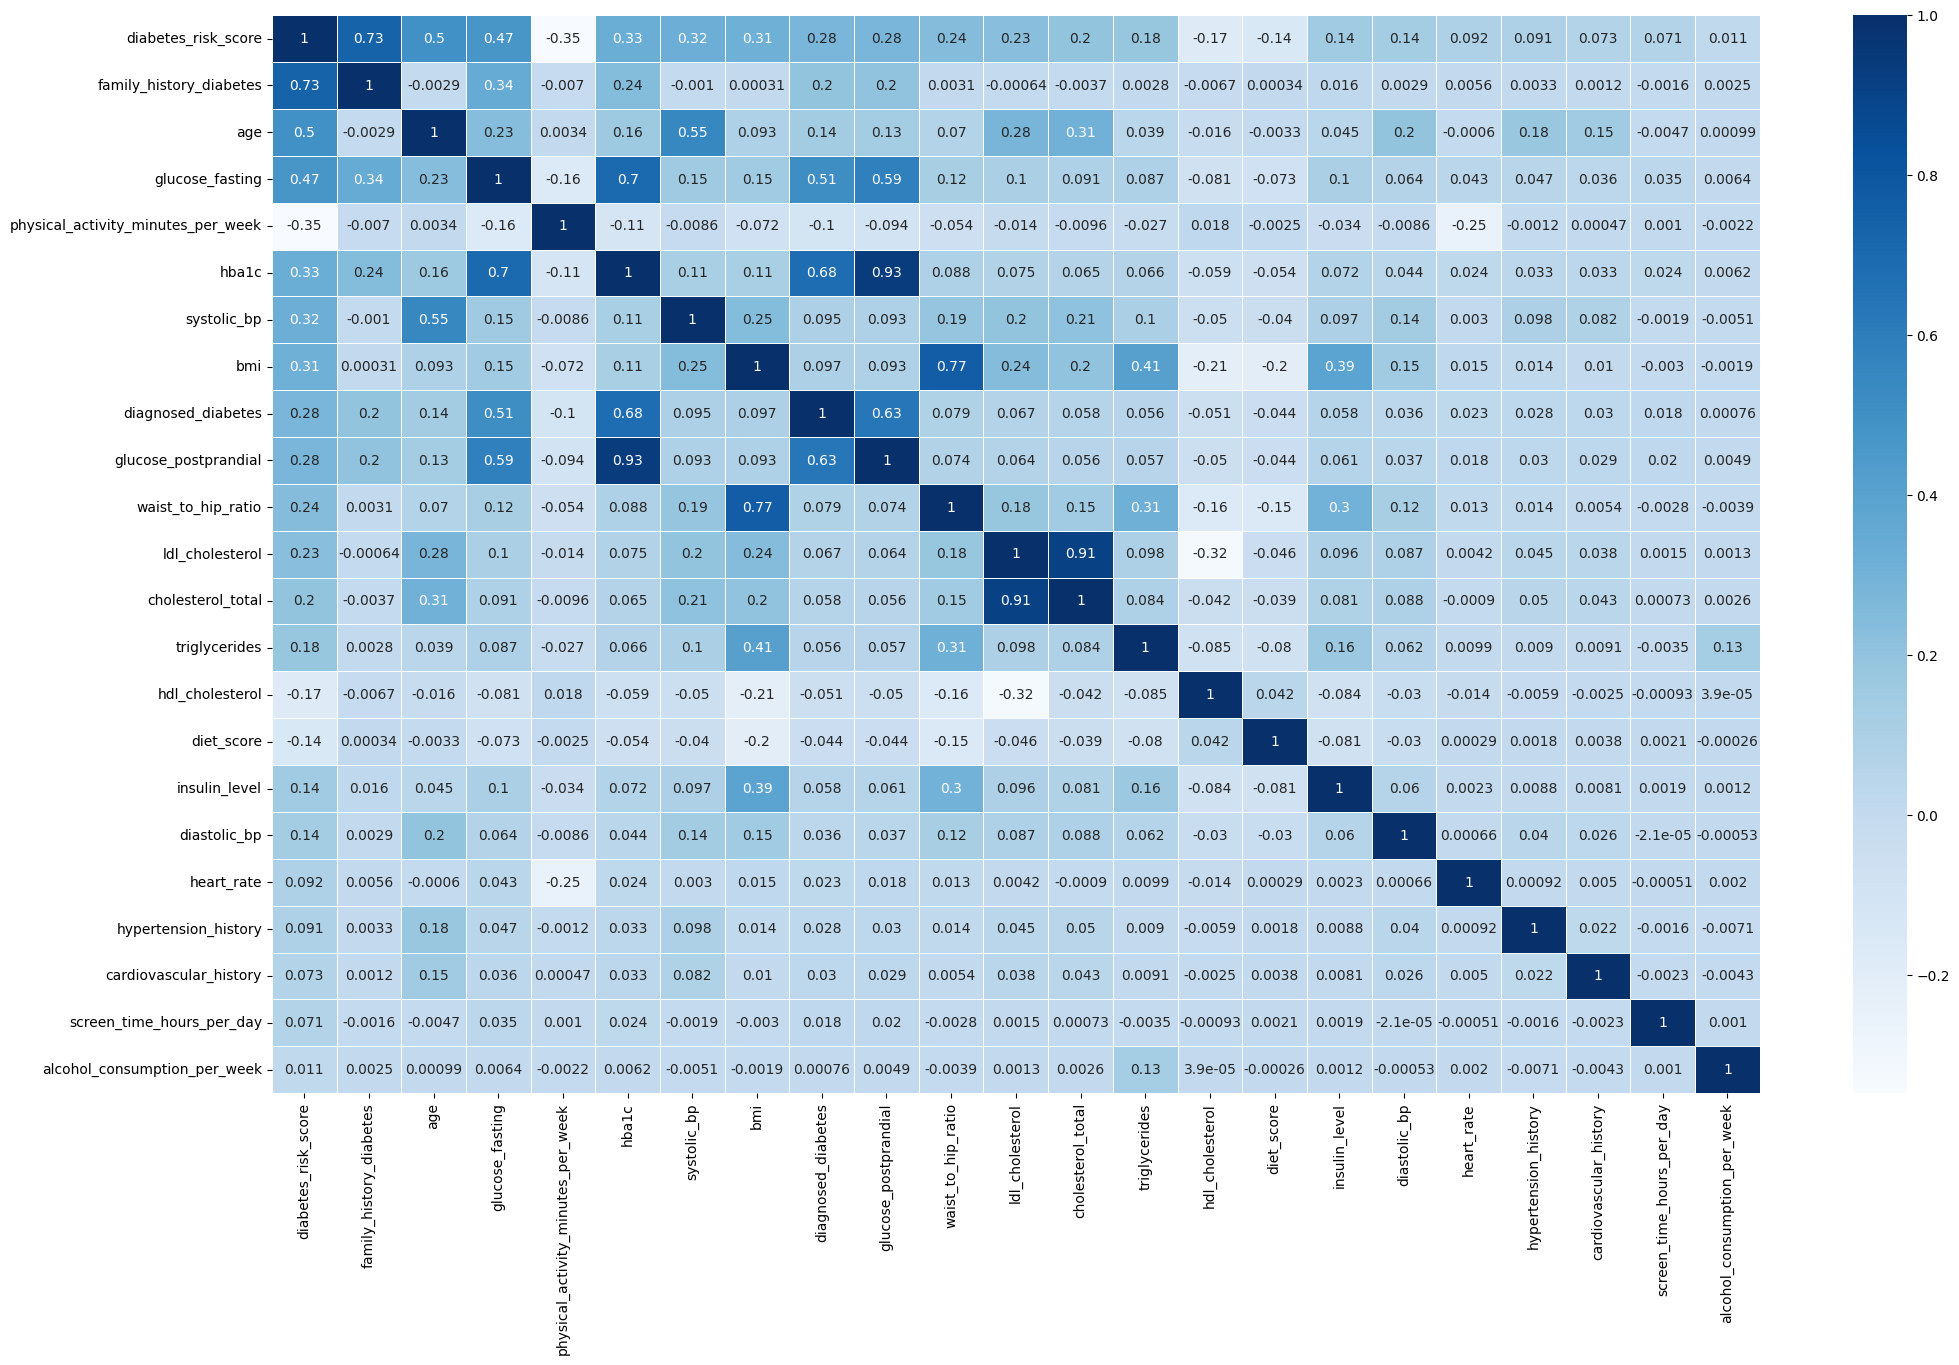

In [16]:
corr_matrix = df_sklearn_encoded[correlation_values1_limited_list].corr()
plt.figure(figsize=(24, 14))
ax = sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap="Blues")
ax.set_xticklabels(ax.get_xticklabels(), ha='center')
ax.set_yticklabels(ax.get_yticklabels(), va='center')
plt.show()

### Try 3 other Categorical Columns and see if they are better correlated to the Target

In [17]:
# Select another subset of Categorical Columns
encoder = OneHotEncoder(sparse_output=False)

categorical_columns_limited2 = ['gender', 'smoking_status', 'diabetes_stage']

encoded_features2 = encoder.fit_transform(df[categorical_columns_limited2])

one_hot_df2 = pd.DataFrame(encoded_features2, columns=encoder.get_feature_names_out(categorical_columns_limited2))

df_sklearn_encoded2 = pd.concat([df.drop(categorical_columns, axis=1), one_hot_df2], axis=1)


In [18]:
df_sklearn_encoded2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                

In [19]:
print(df_sklearn_encoded2.shape)

(100000, 35)


In [20]:
# See Correlation values in relation to the Target value (diabetes_risk_score):
correlation_values2 = abs(df_sklearn_encoded2.corr()['diabetes_risk_score']).sort_values(ascending=False)
print(correlation_values2)

diabetes_risk_score                   1.000000
family_history_diabetes               0.733085
age                                   0.495924
glucose_fasting                       0.469938
physical_activity_minutes_per_week    0.348121
hba1c                                 0.329947
systolic_bp                           0.323591
bmi                                   0.313813
diabetes_stage_Type 2                 0.278540
diagnosed_diabetes                    0.277300
glucose_postprandial                  0.277041
waist_to_hip_ratio                    0.241651
ldl_cholesterol                       0.227772
diabetes_stage_No Diabetes            0.200408
cholesterol_total                     0.197995
triglycerides                         0.180484
hdl_cholesterol                       0.174459
diabetes_stage_Pre-Diabetes           0.171539
diet_score                            0.144891
insulin_level                         0.142210
diastolic_bp                          0.136090
heart_rate   

In [21]:
# keep independent variables and drop the target column that is not needed
correlation_values2_df = pd.DataFrame(correlation_values2).drop('diabetes_risk_score', axis=1)
print(correlation_values2_df)
print(correlation_values2_df.shape)

# limit the column list to the most correlated values (get the top most correlated values)
correlation_values2_limited_df = correlation_values2_df.loc[:'hypertension_history']
print(correlation_values2_limited_df)
# convert to a list
correlation_values2_limited_list = correlation_values2_limited_df.index.to_list()
print(correlation_values2_limited_list)

Empty DataFrame
Columns: []
Index: [diabetes_risk_score, family_history_diabetes, age, glucose_fasting, physical_activity_minutes_per_week, hba1c, systolic_bp, bmi, diabetes_stage_Type 2, diagnosed_diabetes, glucose_postprandial, waist_to_hip_ratio, ldl_cholesterol, diabetes_stage_No Diabetes, cholesterol_total, triglycerides, hdl_cholesterol, diabetes_stage_Pre-Diabetes, diet_score, insulin_level, diastolic_bp, heart_rate, hypertension_history, cardiovascular_history, screen_time_hours_per_day, diabetes_stage_Gestational, diabetes_stage_Type 1, alcohol_consumption_per_week, smoking_status_Current, smoking_status_Never, sleep_hours_per_day, gender_Female, gender_Male, gender_Other, smoking_status_Former]
(35, 0)
Empty DataFrame
Columns: []
Index: [diabetes_risk_score, family_history_diabetes, age, glucose_fasting, physical_activity_minutes_per_week, hba1c, systolic_bp, bmi, diabetes_stage_Type 2, diagnosed_diabetes, glucose_postprandial, waist_to_hip_ratio, ldl_cholesterol, diabetes_st

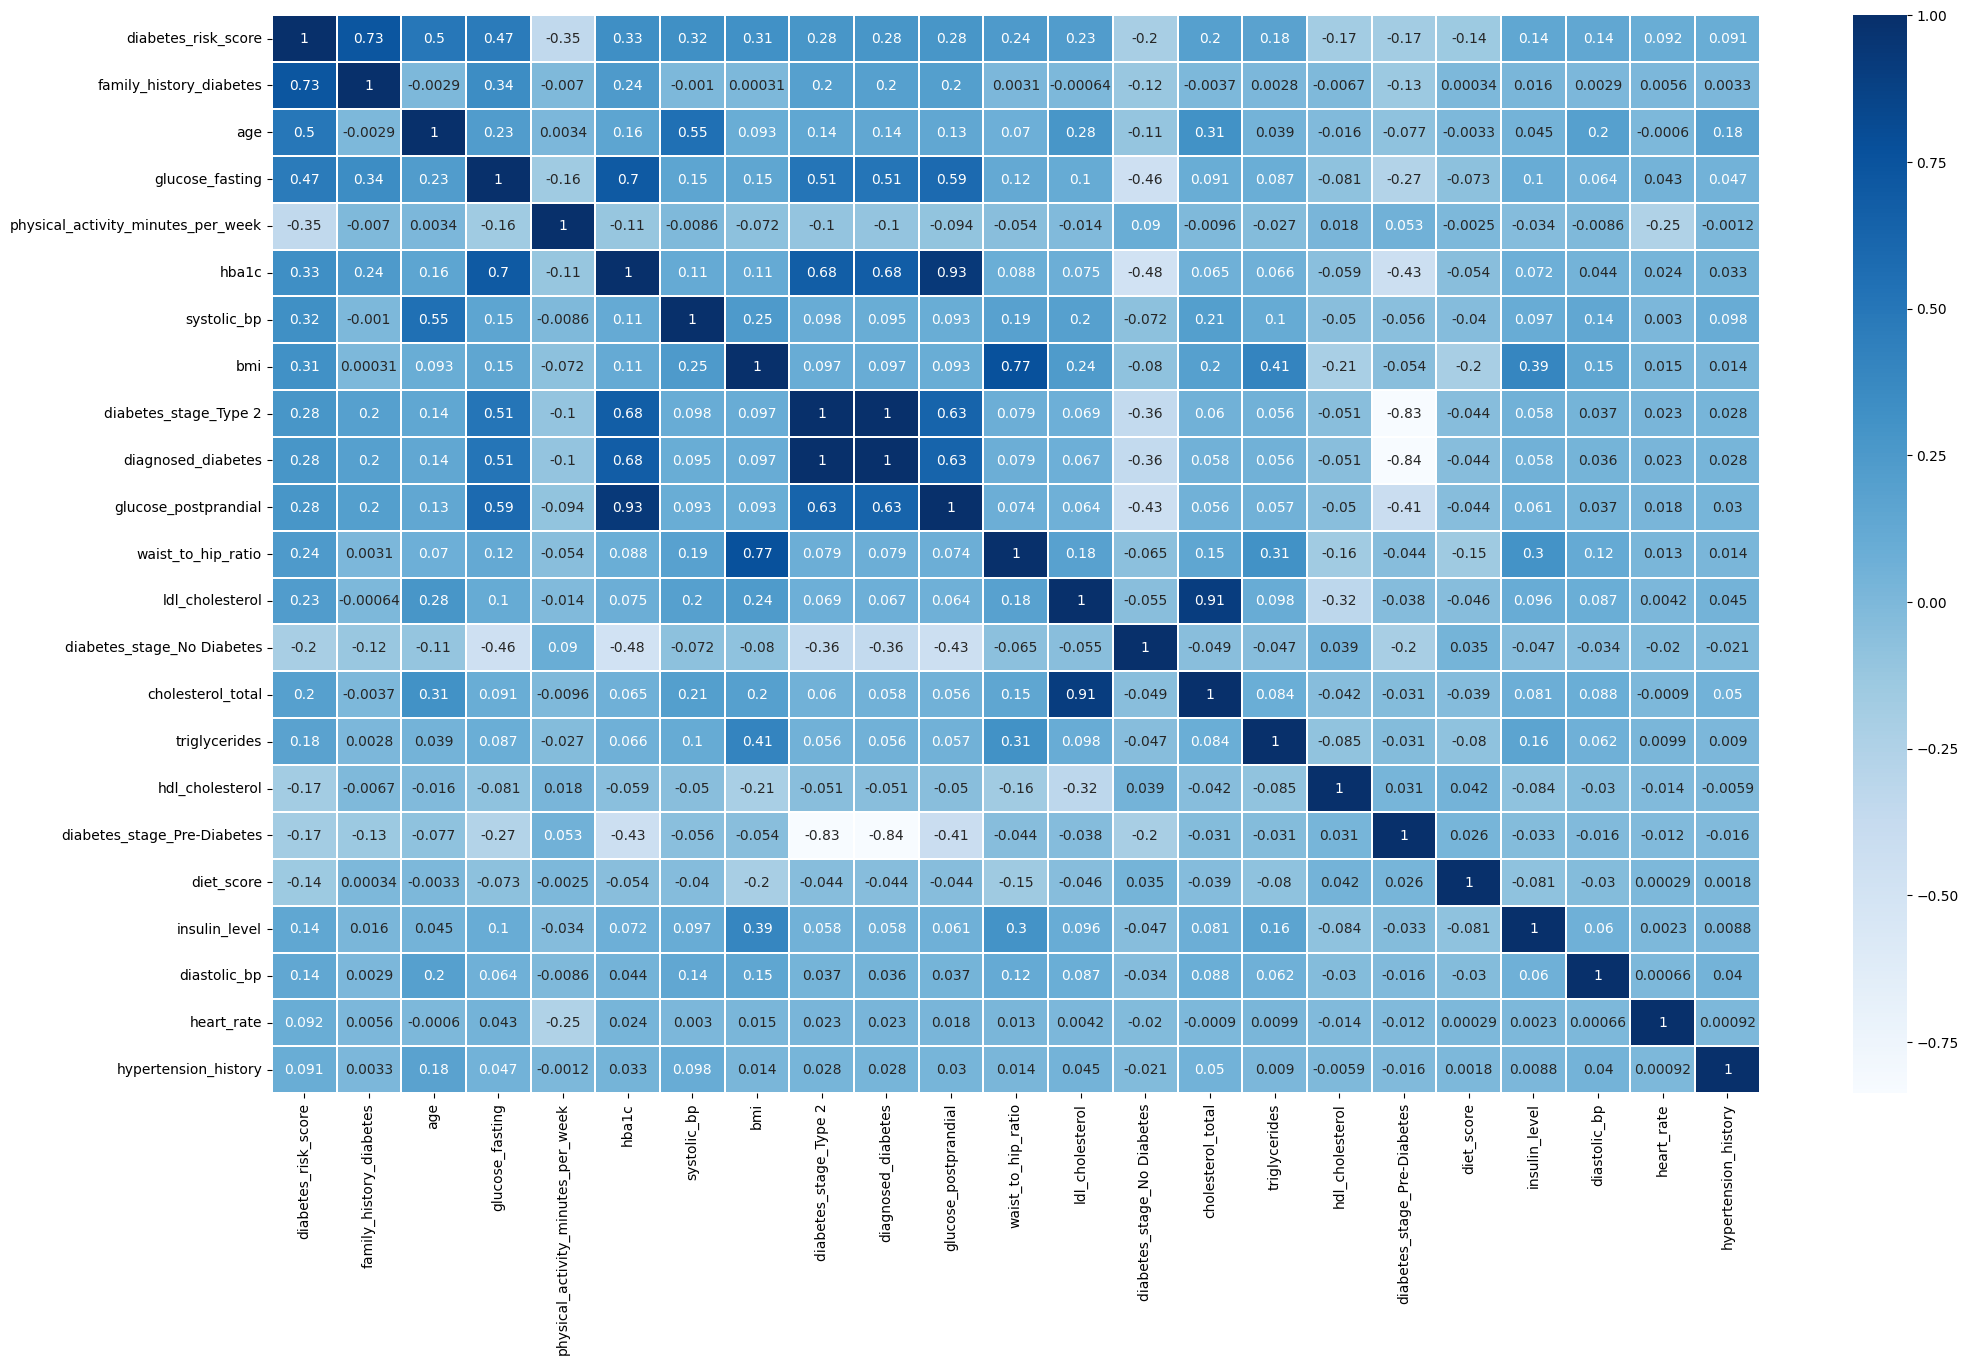

In [22]:
corr_matrix = df_sklearn_encoded2[correlation_values2_limited_list].corr()
plt.figure(figsize=(24, 14))
font = {}
ax = sns.heatmap(corr_matrix, annot=True, linewidths=.1, cmap="Blues")
ax.set_xticklabels(ax.get_xticklabels(), ha='center')
ax.set_yticklabels(ax.get_yticklabels(), va='center')
plt.show()

After adding new Categorical columns: the correlation matrix and the Correlation Heatmap both show better correlation with the Target variable.  

The columns resulting from diabetes_stage (categorical column converted to numerical via one-hot encoding) show especially good correlation with the target.

In [23]:
df_sklearn_encoded2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                

# **3. Diabetes Risk Score - using Linear Regression to calculate Diabetes Risk Score**
 Train the Linear Regression model and make Predictions


In [24]:
# select the independent and dependent variables
temp_values_list = correlation_values2_limited_list
independent_values = temp_values_list
independent_values.remove('diabetes_risk_score')
print(independent_values)

X = df_sklearn_encoded2[independent_values]
y = df_sklearn_encoded2['diabetes_risk_score']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

['family_history_diabetes', 'age', 'glucose_fasting', 'physical_activity_minutes_per_week', 'hba1c', 'systolic_bp', 'bmi', 'diabetes_stage_Type 2', 'diagnosed_diabetes', 'glucose_postprandial', 'waist_to_hip_ratio', 'ldl_cholesterol', 'diabetes_stage_No Diabetes', 'cholesterol_total', 'triglycerides', 'hdl_cholesterol', 'diabetes_stage_Pre-Diabetes', 'diet_score', 'insulin_level', 'diastolic_bp', 'heart_rate', 'hypertension_history']


In [25]:
# using Sklearn's API's to create a regression model
lr_model = LinearRegression()

# fitting the linear regression model
lr_model.fit(X_train, y_train)

# making predictions
lrmodel_y_pred = lr_model.predict(X_test)


In [26]:
# model evaluation
print('mean_squared_error : ', mean_squared_error(y_test, lrmodel_y_pred))
print('mean_absolute_error : ', mean_absolute_error(y_test, lrmodel_y_pred))

lr_model_score = lr_model.score(X_train, y_train)
print('model score: ', lr_model_score)

mean_squared_error :  1.026838139633117
mean_absolute_error :  0.7267848543394688
model score:  0.9878123043861499


In [27]:
# what are the coefficents and Y-intercept used by the model
coeff = lr_model.coef_
intercept = lr_model.intercept_
print(coeff)
print(intercept)

[ 1.59585449e+01  2.76336227e-01  4.90969180e-03 -3.51638781e-02
 -7.41868703e-03  1.71670159e-04  4.45531834e-01 -2.21616250e-02
  1.81326504e-01  2.58700504e-04 -8.42958724e-02  1.62826103e-03
  1.48764665e-01 -1.38281711e-03  1.28664826e-02 -9.45827473e-02
  1.66739340e-01 -5.01858211e-01  1.67205613e-03  5.34228047e-04
  3.53597214e-04  1.12118126e-04]
11.559582532401837


Visualize the performance of the model: plot predicted vs actual values using a KDE plot

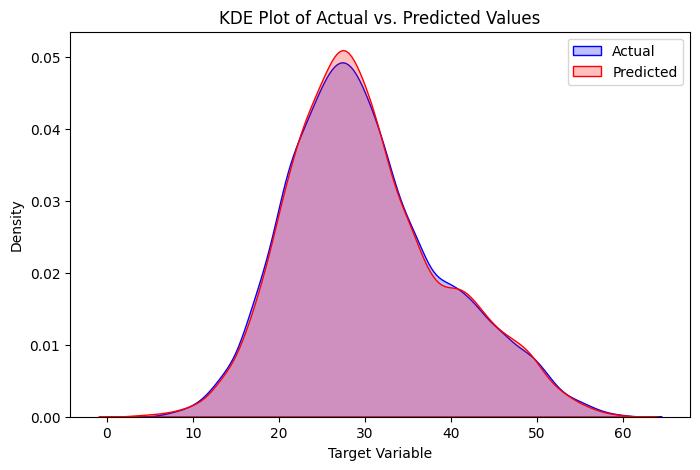

In [28]:
# Plotting KDE for Observed vs. Predicted Values
plt.figure(figsize=(8, 5))
sns.kdeplot(y_test, label='Actual', fill=True, color='blue')
sns.kdeplot(lrmodel_y_pred, label='Predicted', fill=True, color='red')
plt.xlabel('Target Variable')
plt.ylabel('Density')
plt.title('KDE Plot of Actual vs. Predicted Values')
plt.legend()
plt.show()

Result: the linear regression model did very well. It scores very well on accuracy when predicting the risk score of diabetes.

# **4. Calculate Diabetes Risk Score** also using Linear Regression but by **using Stochastic Gradient Descent method instead**

From Sklearn SGDRegressor documentation: "The SGDRegressor class in Scikit-Learn is a linear model fitted by minimizing a regularized empirical loss with Stochastic Gradient Descent (SGD). SGD is an optimization technique that updates the model parameters iteratively by considering one training example at a time, making it efficient for large-scale and sparse machine learning problems."



In [45]:
# To uniform the feature values. But mainly used here because SGDRegressor is
# sensitive to features having different scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
# Create the model and train it
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, learning_rate='invscaling', eta0=0.01, random_state=42)
sgd_reg.fit(X_train_scaled, y_train)

# Perform predictions
y_pred = sgd_reg.predict(X_test_scaled)

In [47]:
# evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

lr_model_score = lr_model.score(X_train_scaled, y_train)
print(f"SGD model score: {lr_model_score}")

Mean Squared Error: 1.032352316881561
SGD model score: -4.703032118725362


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [52]:
# Create and run another SGD regression model
# and monitor Mean Squared Error vs Gradient Descent
sgd_reg_model = SGDRegressor(max_iter=1, tol=None, warm_start=True, learning_rate='invscaling', eta0=0.01, random_state=42)
epochs = 100
mean_sq_error_list = []

for iteration in range(epochs):
    sgd_reg_model.fit(X_train_scaled, y_train)
    y_pred = sgd_reg_model.predict(X_train_scaled)
    mse = mean_squared_error(y_train, y_pred)
    mean_sq_error_list.append(mse)

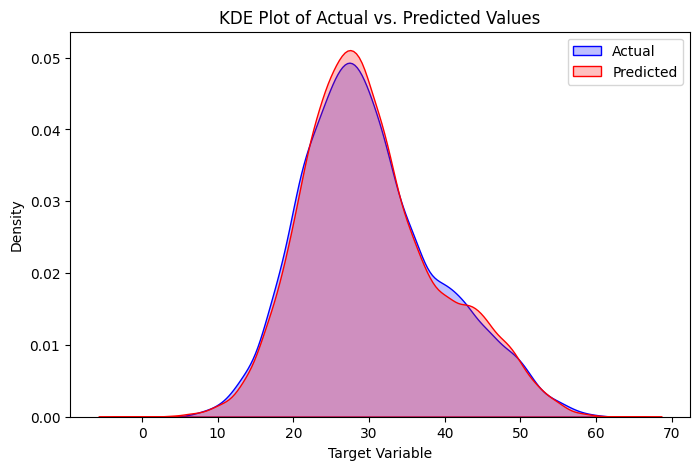

In [53]:
# Plotting KDE for Observed vs. Predicted Values
plt.figure(figsize=(8, 5))
sns.kdeplot(y_test, label='Actual', fill=True, color='blue')
sns.kdeplot(y_pred, label='Predicted', fill=True, color='red')
plt.xlabel('Target Variable')
plt.ylabel('Density')
plt.title('KDE Plot of Actual vs. Predicted Values')
plt.legend()
plt.show()

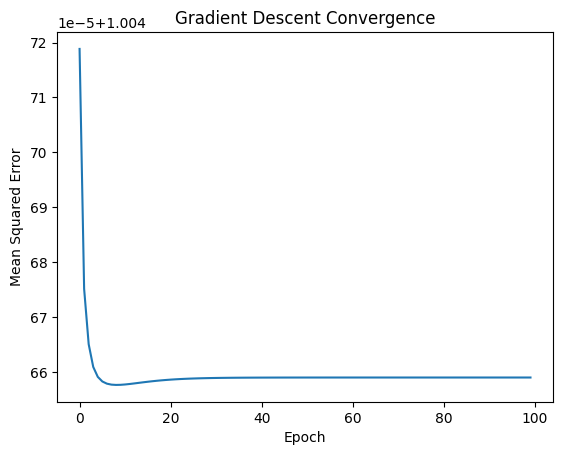

In [54]:
plt.plot(np.arange(epochs), mean_sq_error_list)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Gradient Descent Convergence')
plt.show()

Results: the SGDRegressor model did not perform any better than the regular Linear Regression model.  In fact, it performed slightly worse.

However, the SGDRegressor relies on a few hyperparameters that need tuning.  These may be tuned over several runs by using GridSearchCV.  This is left as a future excercise.

# **5. Diabetes Diagnosis Prediction (Yes or No) using Logistic Regression for Binary Classification** - with the same Dataset


In [55]:
# Read the dataset from CSV file into data frame
predict_diabetes_df = pd.read_csv(path + '/diabetes_dataset.csv')

In [56]:
predict_diabetes_df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [57]:
predict_diabetes_df.shape

(100000, 31)

(array([40002.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 59998.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

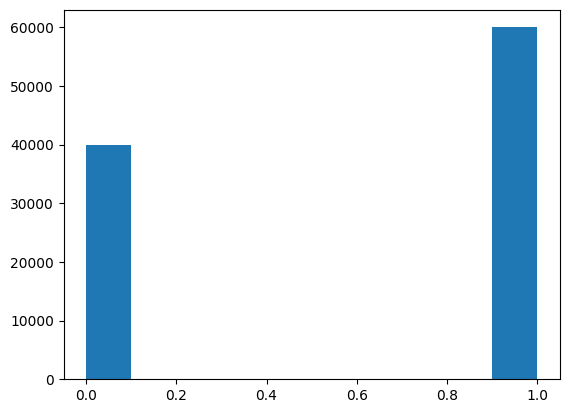

In [58]:
# Spread of Diagnosed Diabetes data
plt.hist(predict_diabetes_df['diagnosed_diabetes'])

In [59]:
# Select a subset of Categorical columns only
encoder = OneHotEncoder(sparse_output=False)

categorical_columns_limited2 = ['gender', 'smoking_status', 'diabetes_stage']

encoded_features3 = encoder.fit_transform(predict_diabetes_df[categorical_columns_limited2])

one_hot_df3 = pd.DataFrame(encoded_features3, columns=encoder.get_feature_names_out(categorical_columns_limited2))

df_sklearn_encoded3 = pd.concat([predict_diabetes_df.drop(categorical_columns, axis=1), one_hot_df3], axis=1)


In [60]:
df_sklearn_encoded3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                

In [61]:
# See Correlation values in relation to the Target value (diagnosed_diabetes):
correlation_values3 = abs(df_sklearn_encoded3.corr()['diagnosed_diabetes']).sort_values(ascending=False)
print(correlation_values3)

diagnosed_diabetes                    1.000000
diabetes_stage_Type 2                 0.995349
diabetes_stage_Pre-Diabetes           0.837142
hba1c                                 0.679397
glucose_postprandial                  0.629832
glucose_fasting                       0.510919
diabetes_stage_No Diabetes            0.360676
diabetes_risk_score                   0.277300
family_history_diabetes               0.197926
age                                   0.137713
physical_activity_minutes_per_week    0.100774
bmi                                   0.097057
systolic_bp                           0.095481
waist_to_hip_ratio                    0.078918
ldl_cholesterol                       0.067475
cholesterol_total                     0.058173
insulin_level                         0.057715
triglycerides                         0.056230
hdl_cholesterol                       0.051227
diet_score                            0.044298
diastolic_bp                          0.035619
cardiovascula

In [62]:
# Get a list of Indepent Variables
correlation_values3_df = pd.DataFrame(correlation_values3).drop('diagnosed_diabetes', axis=1)
print(correlation_values3_df.shape)

# convert to a list
correlation_values3_list = correlation_values3_df.index.to_list()
print(correlation_values3_list)


(35, 0)
['diagnosed_diabetes', 'diabetes_stage_Type 2', 'diabetes_stage_Pre-Diabetes', 'hba1c', 'glucose_postprandial', 'glucose_fasting', 'diabetes_stage_No Diabetes', 'diabetes_risk_score', 'family_history_diabetes', 'age', 'physical_activity_minutes_per_week', 'bmi', 'systolic_bp', 'waist_to_hip_ratio', 'ldl_cholesterol', 'cholesterol_total', 'insulin_level', 'triglycerides', 'hdl_cholesterol', 'diet_score', 'diastolic_bp', 'cardiovascular_history', 'hypertension_history', 'heart_rate', 'screen_time_hours_per_day', 'gender_Other', 'diabetes_stage_Type 1', 'diabetes_stage_Gestational', 'gender_Female', 'gender_Male', 'smoking_status_Former', 'smoking_status_Never', 'alcohol_consumption_per_week', 'sleep_hours_per_day', 'smoking_status_Current']


In [63]:
# train the model on the training data
X = df_sklearn_encoded3[correlation_values3_list]
y = df_sklearn_encoded3['diagnosed_diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

logistic_reg_classifier_model = LogisticRegression(max_iter=10000, random_state=42)

logistic_reg_classifier_model.fit(X_train, y_train)

# then use the model to make predictions
logistic_reg_y_pred = logistic_reg_classifier_model.predict(X_test)

In [64]:
#Model evaluation
acc = accuracy_score(y_test, logistic_reg_y_pred) * 100
print(f"Logistic Regression model accuracy_score: {acc:.2f}%")

accuracy = logistic_reg_classifier_model.score(X_train, y_train)
print(f"Logistic Regression model score: {acc:.2f}%")

print('mean_squared_error : ', mean_squared_error(y_test, logistic_reg_y_pred))
print('mean_absolute_error : ', mean_absolute_error(y_test, logistic_reg_y_pred))

Logistic Regression model accuracy_score: 100.00%
Logistic Regression model score: 100.00%
mean_squared_error :  0.0
mean_absolute_error :  0.0


In [65]:
# get coefficients and Y-intercept from the model
coeff = logistic_reg_classifier_model.coef_
intercept = logistic_reg_classifier_model.intercept_
print(coeff)
print(intercept)

[[ 6.87211600e+00  6.29110550e+00 -5.67836639e+00  7.25063082e-01
   2.12588231e-02  2.39644866e-02 -1.24024743e+00  1.54520667e-04
   1.74846799e-01  6.68241231e-03 -2.61779699e-03 -7.79515389e-02
  -1.84814671e-02 -1.58339170e-01  9.98075472e-03 -1.25755064e-02
  -8.37393138e-04  9.82287231e-04 -1.85253448e-02 -1.51503532e-01
  -4.58749837e-02  2.22785978e-02  5.27480643e-02 -4.79278510e-02
  -4.49237214e-02 -1.22095426e-02  1.32786520e-01  2.24785803e-01
  -8.07294277e-02 -1.76997028e-01 -8.29230142e-02 -1.23546242e-01
   6.58965403e-02  3.99084258e-02 -6.34667418e-02]]
[-0.28706152]


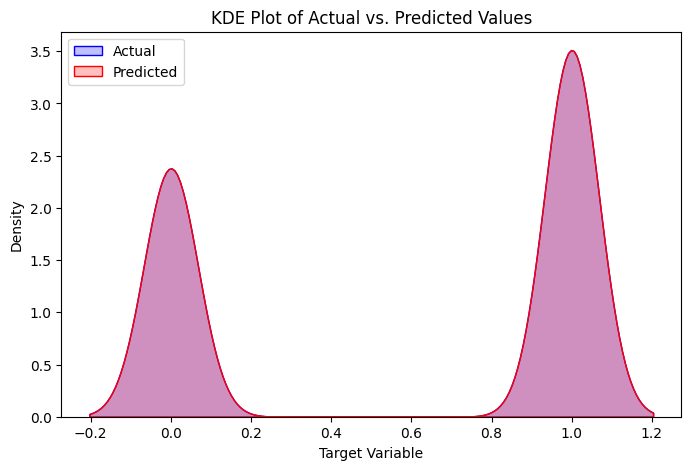

In [66]:
# Plotting KDE for Observed vs. Predicted Values
plt.figure(figsize=(8, 5))
sns.kdeplot(y_test, label='Actual', fill=True, color='blue')
sns.kdeplot(logistic_reg_y_pred, label='Predicted', fill=True, color='red')
plt.xlabel('Target Variable')
plt.ylabel('Density')
plt.title('KDE Plot of Actual vs. Predicted Values')
plt.legend()
plt.show()

Result: the logistic regression model did exceptionally well.  It scored 100% on accuracy when predicting the diagnosis of diabetes.  